In [2]:
BASE_DIR = "."

In [3]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from preprocessing import preprocessing

df = pd.read_csv("data/train.csv")
valid_df = pd.read_csv("data/valid.csv")

preprocessing(df)
preprocessing(valid_df)

le_type = LabelEncoder()
le_result = LabelEncoder()
le_field_zone = LabelEncoder()

df["type_name_encoded"] = le_type.fit_transform(df["type_name"])
df["result_encoded"] = le_result.fit_transform(df["result_name"])
df["field_zone_encoded"] = le_field_zone.fit_transform(df["field_zone"])

valid_df["type_name_encoded"] = le_type.transform(valid_df["type_name"])
valid_df["result_encoded"] = le_result.transform(valid_df["result_name"])
valid_df["field_zone_encoded"] = le_field_zone.transform(valid_df["field_zone"])

df.to_csv("data/train_converted.csv", index=False)
valid_df.to_csv("data/valid_converted.csv", index=False)

In [ ]:

df = pd.read_csv("data/train.csv")
valid_df = pd.read_csv("data/valid.csv")

pred_df = pd.concat([df, valid_df])
pred_ㅇㄹ

In [4]:
import torch

TRAIN_PATH = f"{BASE_DIR}/data/train_converted.csv"
VALID_PATH = f'{BASE_DIR}/data/valid_converted.csv'
BATCH_SIZE = 64
LR = 0.001
HIDDEN_DIM = 64
NUM_LSTM_LAYERS = 1
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cpu


In [9]:
import torch.nn as nn
from typing import Dict
import pandas as pd

EMBEDDING_DIMS: Dict[str, int] = {
    'type_name': 8,
    'result_name': 4,
    'player_id': 64,
    'team_id': 16,
    'field_zone': 4
}

VOCAB_SIZES: Dict[str, int] = {
    'type_name': 26 + 1,
    'result_name': 9 + 1,
    'player_id': 534728 + 1, # player_id의 최대값 + 1 + OOV 슬롯
    'team_id': 4658 + 1, # team_id의 최대값 + 1 + OOV 슬롯,
    'field_zone': 6
}

numerical_features = [
    'nor_start_x',
    'nor_start_y',
    'nor_end_x',
    'nor_end_y',
    'is_home',
    'duration',
    'movement_distance',
    'ball_velocity',
    'time_seconds',
    'dx',
    'dy',
    'goal_distance',
    'success_rate',
    'cumulative_movement_distance'
]
categorical_features = ['type_name_encoded', 'result_encoded', 'player_id', 'team_id', 'field_zone_encoded']


class FeatureEmbeddingLayer(nn.Module):
    def __init__(self, vocab_sizes: Dict[str, int], embedding_dims: Dict[str, int], num_numerical_features: int):
        super(FeatureEmbeddingLayer, self).__init__()

        self.type_layer = nn.Embedding(vocab_sizes['type_name'], embedding_dims['type_name'])
        self.result_layer = nn.Embedding(vocab_sizes['result_name'], embedding_dims['result_name'])
        self.player_layer = nn.Embedding(vocab_sizes['player_id'], embedding_dims['player_id'])
        self.team_layer = nn.Embedding(vocab_sizes['team_id'], embedding_dims['team_id'])
        self.field_zone_layer = nn.Embedding(vocab_sizes['field_zone'], embedding_dims['field_zone'])

        self.final_feature_dim = sum(embedding_dims.values()) + num_numerical_features

    def forward(self, x_cat: torch.Tensor, x_num: torch.Tensor) -> torch.Tensor:
        """
        x_cat: (Batch, Sequence Length, 4) - 정수 ID
        x_num: (Batch, Sequence Length, Num Numericals) - 실수 값
        """

        # 임베딩
        type_embedded = self.type_layer(x_cat[:, :, 0])
        result_embedded = self.result_layer(x_cat[:, :, 1])
        player_embedded = self.player_layer(x_cat[:, :, 2])
        team_embedded = self.team_layer(x_cat[:, :, 3])
        field_zone_embedded = self.field_zone_layer(x_cat[:, :, 4])

        # 임베딩된 범주형 특성
        x_embedded = torch.cat([
            type_embedded,
            result_embedded,
            player_embedded,
            team_embedded,
            field_zone_embedded
        ], dim=2)

        # 범주형 + 수치형 특성 -> 최종 벡터
        x_final = torch.cat([x_embedded, x_num], dim=2)

        return x_final

In [10]:
from torch.nn.utils.rnn import pack_padded_sequence

class PositionPredictor(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int):
        super().__init__()
        self.embedding_layer = FeatureEmbeddingLayer(
            vocab_sizes=VOCAB_SIZES,
            embedding_dims=EMBEDDING_DIMS,
            num_numerical_features=len(numerical_features)
        )


        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=NUM_LSTM_LAYERS,
            batch_first=True,
            bidirectional=True,
        )

        self.fc = nn.Linear(hidden_dim * 2, 2)

    def forward(self, x_cat, y_num, lengths):
        inputs = self.embedding_layer(x_cat, y_num)
        packed = pack_padded_sequence(inputs, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, c_n) = self.lstm(packed)
        final_hidden_state = torch.cat([h_n[-2], h_n[-1]], dim=1)
        out = self.fc(final_hidden_state)

        return out

class EuclideanDistanceLoss(nn.Module):
    def forward(self, pred, target):
        # pred: (B, 2), target: (B, 2)
        distance = torch.sqrt(torch.sum((pred - target) ** 2, dim=1))  # (B,)
        return distance.mean()

criterion = EuclideanDistanceLoss()
model = PositionPredictor(input_dim=sum(EMBEDDING_DIMS.values()) + len(numerical_features), hidden_dim=HIDDEN_DIM).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

In [11]:
from tqdm import tqdm
import pandas as pd
import numpy as np

train_df = pd.read_csv(TRAIN_PATH)
valid_df = pd.read_csv(VALID_PATH)
def create_episode_data(df, sequence_length=5):  # ← 시퀀스 길이 설정
    episodes_cat = []
    episodes_num = []
    targets = []

    for _, g in tqdm(df.groupby("game_episode")):
        g = g.reset_index(drop=True)

        if len(g) < sequence_length + 1:  # ← 수정
            continue

        # Rolling Window로 시퀀스 생성
        for i in range(len(g) - sequence_length):
            # 과거 sequence_length개 액션
            cat_feats = g.loc[i:i+sequence_length-1][categorical_features].values
            num_feats = g.loc[i:i+sequence_length-1][numerical_features].values

            seq_cat = np.array(cat_feats, dtype="int64")  # (5, 4)
            seq_num = np.array(num_feats, dtype="float32")  # (5, 6)

            # 다음 액션(i+sequence_length)의 시작 위치를 정답으로
            target = np.array([
                g.loc[i + sequence_length]['nor_start_x'],
                g.loc[i + sequence_length]['nor_start_y']
            ], dtype="float32")

            episodes_cat.append(seq_cat)
            episodes_num.append(seq_num)
            targets.append(target)

    print(f"총 에피소드 수: {len(episodes_cat)}")
    return episodes_cat, episodes_num, targets


In [21]:
import pickle

t_epic_cat, t_epic_num, t_targets = create_episode_data(train_df)
v_epic_cat, v_epic_num, v_targets = create_episode_data(valid_df)

with open('./data/train_epic.pkl', 'wb') as f:
    pickle.dump((t_epic_cat, t_epic_num, t_targets), f)

with open('./data/valid_epic.pkl', 'wb') as f:
    pickle.dump((v_epic_cat, v_epic_num, v_targets), f)

100%|██████████| 14022/14022 [01:15<00:00, 185.61it/s]


총 에피소드 수: 258308


100%|██████████| 1413/1413 [00:07<00:00, 194.43it/s]


총 에피소드 수: 24779


In [23]:
import pickle

with open("./data/train_epic.pkl", "rb") as f:
    t_epic_cat, t_epic_num, t_targets = pickle.load(f)

with open("./data/valid_epic.pkl", "rb") as f:
    v_epic_cat, v_epic_num, v_targets = pickle.load(f)

In [24]:
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

class EpisodeDataset(Dataset):
    def __init__(self, episodes_cat, episodes_num, targets):
        self.episodes_num = episodes_num
        self.episodes_cat = episodes_cat
        self.targets = targets

    def __len__(self):
        return len(self.episodes_cat)

    def __getitem__(self, idx):
        seq_cat = torch.tensor(self.episodes_cat[idx], dtype=torch.long)
        seq_num = torch.tensor(self.episodes_num[idx], dtype=torch.float32)
        tgt = torch.tensor(self.targets[idx])
        length = seq_cat.size(0)
        return seq_cat, seq_num, length, tgt

def collate_fn(batch):
    seqs_cat, seqs_num, lengths, tgts = zip(*batch)
    seqs_cat = pad_sequence(seqs_cat, batch_first=True, padding_value=0)
    seqs_num = pad_sequence(seqs_num, batch_first=True, padding_value=0.0)
    lengths = torch.tensor(lengths, dtype=torch.long)
    tgts = torch.stack(tgts, dim=0)
    return seqs_cat, seqs_num, lengths, tgts

train_loader = DataLoader(
    EpisodeDataset(t_epic_cat, t_epic_num, t_targets),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    drop_last=True,
)

valid_loader = DataLoader(
    EpisodeDataset(v_epic_cat, v_epic_num, v_targets),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    drop_last=True,
)

print("train episodes:", len(t_epic_cat), "valid episodes:", len(v_epic_cat))

train episodes: 258308 valid episodes: 24779


In [ ]:
from tqdm import tqdm

EPOCHS=20
best_valid_loss = float('inf')
best_model_state = None
train_losses = []
valid_losses = []
train_rmse = []
valid_rmse = []

for epoch in range(EPOCHS):
    # Train
    model.train()
    total_loss = []
    for batch_idx, (x_cat, x_num, length, y) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")):
        x_cat, x_num, y = x_cat.to(DEVICE), x_num.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(x_cat, x_num, length)
        loss = criterion(outputs, y)
        
        loss.backward()
        optimizer.step()

        total_loss.append(loss.item())
    avg_train_loss = np.mean(total_loss)
    train_rmse.append(np.sqrt(total_loss))
    train_losses.append(avg_train_loss)
    scheduler.step()

    # Validation
    model.eval()
    valid_loss = []
    with torch.no_grad():
        for x_cat, x_num, length, y in tqdm(valid_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Valid]"):
            x_cat, x_num, y = x_cat.to(DEVICE), x_num.to(DEVICE), y.to(DEVICE)
            outputs = model(x_cat, x_num, length)
            loss = criterion(outputs, y)
            valid_loss.append(loss.item())

    avg_valid_loss = np.mean(valid_loss)
    valid_rmse.append(np.sqrt(avg_valid_loss))
    valid_losses.append(avg_valid_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}], Train Loss: {avg_train_loss:.4f}, Valid Loss: {avg_valid_loss:.4f}")

    # 최고 성능 모델 저장
    if avg_valid_loss < best_valid_loss:
        best_valid_loss = avg_valid_loss
        best_model_state = model.state_dict()

print(f"  → Best model saved! (Valid Loss: {best_valid_loss:.4f})")
torch.save(best_model_state, 'best_model_rolling_window.pth')

print("\n=== Training Complete ===")

Epoch 1/20 [Train]:   0%|          | 0/4036 [00:00<?, ?it/s]

loss 0.5704537630081177
  → Best model saved! (Valid Loss: inf)

=== Training Complete ===


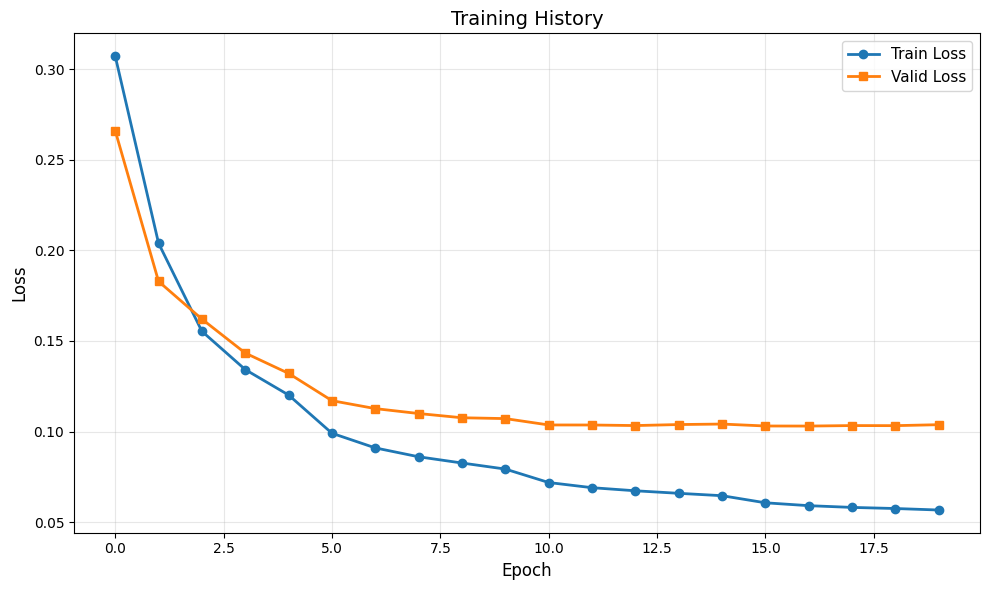

✓ training_history.png 저장됨


In [ ]:
# 학습 곡선 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss', marker='o', linewidth=2)
plt.plot(valid_losses, label='Valid Loss', marker='s', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training History', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('training_history.png', dpi=100)
plt.show()

print("✓ training_history.png 저장됨")

In [ ]:
print("\n=== 학습 평가 ===")

# 1. Train/Valid 차이
train_final = train_losses[9]
valid_final = valid_losses[9]
diff_ratio = abs(train_final - valid_final) / valid_final * 100

print(f"Train Loss: {train_final:.4f}")
print(f"Valid Loss: {valid_final:.4f}")
print(f"차이: {diff_ratio:.2f}%")

if diff_ratio < 5:
    print("  ✓ 과적합 없음")
elif diff_ratio < 15:
    print("  ⚠️ 약간의 과적합")
else:
    print("  ❌ 심한 과적합")

# 2. 개선 추세
improvement = (valid_losses[0] - valid_losses[-1]) / valid_losses[0] * 100
print(f"\nValid Loss 개선율: {improvement:.2f}%")

if improvement > 30:
    print("  ✓ 좋은 개선")
elif improvement > 10:
    print("  ⚠️ 중간 수준")
else:
    print("  ❌ 개선 부족 → 더 많은 에포크 필요")

# 3. RMSE 기준
rmse = np.sqrt(valid_final)
print(f"\nRMSE: {rmse:.4f}")

if rmse < 0.1:
    print("  ✓ 매우 좋음")
elif rmse < 0.2:
    print("  ✓ 좋음")
elif rmse < 0.3:
    print("  ⚠️ 중간")
else:
    print("  ❌ 개선 필요")


=== 학습 평가 ===
Train Loss: 0.0793
Valid Loss: 0.1072
차이: 26.00%
  ❌ 심한 과적합

Valid Loss 개선율: 60.99%
  ✓ 좋은 개선

RMSE: 0.3273
  ❌ 개선 필요


In [ ]:
from sklearn.preprocessing import LabelEncoder
import numpy as np
from tqdm import tqdm
from proprocessing import preprocessing

# OOV(Out-Of-Vocabulary) 레이블을 처리하는 헬퍼 함수
def safe_label_encoder_transform(le: LabelEncoder, data: pd.Series, unknown_token_idx: int) -> np.ndarray:
    """
    LabelEncoder를 사용하여 데이터를 변환하고, 알 수 없는(unseen) 레이블을 지정된 unknown_token_idx로 매핑합니다.
    NaN 값도 unknown_token_idx로 매핑합니다.
    """
    transformed = []
    for item in data:
        if pd.isna(item): # NaN 값 명시적 처리
            transformed.append(unknown_token_idx)
            continue
        try:
            # LabelEncoder는 1차원 배열 형태를 예상하므로 [item]으로 전달합니다.
            transformed.append(le.transform([item])[0])
        except ValueError:
            # item이 le.classes_에 없으면 알 수 없는 레이블입니다.
            transformed.append(unknown_token_idx)
    return np.array(transformed, dtype=np.int64) # torch.long을 위해 int64 타입 보장

EPOCHS = 10

df = pd.read_csv("data/train.csv")
valid_df = pd.read_csv("data/valid.csv")

pred_df = pd.concat([df, valid_df], axis=0, ignore_index=True)
pred_df = preprocessing(pred_df)

# 모든 고유 레이블 (훈련, 검증, 테스트 데이터셋에서) 수집
all_type_names = set(pred_df["type_name"].unique())
all_result_names = set(pred_df["result_name"].dropna().unique())
all_player_ids = set(pred_df["player_id"].unique())
all_team_ids = set(pred_df["team_id"].unique())
all_field_zones = set(pred_df['field_zone'])

temp_test_meta = pd.read_csv(f"{BASE_DIR}/data/test.csv")
for _, row in tqdm(temp_test_meta.iterrows(), total=len(temp_test_meta), desc="Collecting test labels"):
    g = pd.read_csv(f'{BASE_DIR}/data/{row["path"]}').reset_index(drop=True)
    all_type_names.update(g["type_name"].unique())
    all_result_names.update(g["result_name"].dropna().unique())
    all_player_ids.update(g["player_id"].unique())
    all_team_ids.update(g["team_id"].unique())

# 전체 레이블 세트에 LabelEncoder 피팅
f_le_type = LabelEncoder()
f_le_type.fit(list(all_type_names))

f_field_zone = LabelEncoder()
f_field_zone.fit(list(all_field_zones))

f_le_result = LabelEncoder()
f_le_result.fit(list(all_result_names))

# type_name 및 result_name에 대한 OOV 인덱스 결정
# 이는 LabelEncoder가 학습한 클래스 수와 같습니다.
type_name_oov_idx = len(f_le_type.classes_)
result_name_oov_idx = len(f_le_result.classes_)
field_zone_oov_idx = len(f_le_result.classes_)
# player_id 및 team_id에 대한 OOV 인덱스 결정
# VOCAB_SIZES[key] - 1은 FeatureEmbeddingLayer에서 OOV 슬롯으로 예약된 인덱스입니다.
player_id_oov_idx = VOCAB_SIZES['player_id'] - 1
team_id_oov_idx = VOCAB_SIZES['team_id'] - 1

# safe_label_encoder_transform을 사용하여 변환 적용
pred_df["type_name_encoded"] = safe_label_encoder_transform(f_le_type, pred_df["type_name"], type_name_oov_idx)
pred_df["result_encoded"] = safe_label_encoder_transform(f_le_result, pred_df["result_name"], result_name_oov_idx)
pref_df['field_zone_encoded'] = safe_label_encoder_transform(f_le_result, pred_df["result_name"], result_name_oov_idx)
# player_id 및 team_id에 대한 OOV 처리 (예상 범위를 초과하는 ID를 OOV 인덱스로 매핑)
pred_df["player_id"] = pred_df["player_id"].apply(lambda x: x if x < player_id_oov_idx else player_id_oov_idx)
pred_df["team_id"] = pred_df["team_id"].apply(lambda x: x if x < team_id_oov_idx else team_id_oov_idx)

f_epic_cat, f_epic_num, f_targets = create_episode_data(pred_df)

f_loader = DataLoader(
    EpisodeDataset(f_epic_cat, f_epic_num, f_targets),
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    drop_last=True,
)

model = PositionPredictor(input_dim=sum(EMBEDDING_DIMS.values()) + len(numerical_features), hidden_dim=HIDDEN_DIM).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

model.train()
for epoch in range(EPOCHS):
    total_loss = []
    for batch_idx, (x_cat, x_num, length, y) in enumerate(tqdm(f_loader, desc=f"Final Training Epoch {epoch+1}/{EPOCHS}")):
        x_cat, x_num, y = x_cat.to(DEVICE), x_num.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(x_cat, x_num, length)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss.append(loss.item())
    scheduler.step()
    avg_loss = np.mean(total_loss)
    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.4f}")

torch.save(model.state_dict(), f'{BASE_DIR}/best_model.pth')

100%|██████████| 1996/1996 [00:52<00:00, 38.17it/s]


총 에피소드 수: 35635


In [ ]:
pred_df['type_name'].unique()

array(['Pass', 'Carry', 'Interception', 'Clearance', 'Duel', 'Recovery',
       'Intervention', 'Throw-In', 'Tackle', 'Pass_Freekick',
       'Pass_Corner', 'Goal Kick', 'Error', 'Take-On', 'Cross', 'Block',
       'Shot', 'Parry', 'Aerial Clearance', 'Catch', 'Hit', 'Foul',
       'Shot_Freekick'], dtype=object)

In [ ]:

import pandas as pd
import os
from tqdm import tqdm


train_df = pd.read_csv('data/train.csv')
valid_df = pd.read_csv('data/valid.csv')

pred_df = pd.concat([train_df, valid_df])

# 모든 고유 레이블 (훈련, 검증, 테스트 데이터셋에서) 수집
all_type_names = set(pred_df["type_name"].unique())
all_result_names = set(pred_df["result_name"].dropna().unique())


temp_test_meta = pd.read_csv(f"{BASE_DIR}/data/test.csv")
for _, row in tqdm(temp_test_meta.iterrows(), total=len(temp_test_meta), desc="Collecting test labels"):
    g = pd.read_csv(f'{BASE_DIR}/data/{row["path"]}').reset_index(drop=True)
    all_type_names.update(g["type_name"].unique())
    all_result_names.update(g["result_name"].dropna().unique())

print(all_type_names)
print(all_result_names)

{'Pass_Corner', 'Pass', 'Intervention', 'Goal Kick', 'Tackle', 'Cross', 'Foul', 'Hit', 'Recovery', 'Parry', 'Penalty Kick', 'Throw-In', 'Catch', 'Handball_Foul', 'Shot', 'Block', 'Aerial Clearance', 'Take-On', 'Duel', 'Clearance', 'Pass_Freekick', 'Deflection', 'Interception', 'Error', 'Shot_Freekick', 'Carry'}
{'Unsuccessful', 'Low Quality Shot', 'On Target', 'Off Target', 'Yellow_Card', 'Blocked', 'Successful', 'Keeper Rush-Out'}
{np.int64(77828), np.int64(77845), np.int64(143410), np.int64(407605), np.int64(501836), np.int64(356596), np.int64(188514), np.int64(61616), np.int64(250036), np.int64(250037), np.int64(358583), np.int64(61623), np.int64(61626), np.int64(534721), np.int64(250054), np.int64(250055), np.int64(250056), np.int64(250057), np.int64(534727), np.int64(250060), np.int64(61645), np.int64(250075), np.int64(250076), np.int64(250079), np.int64(528608), np.int64(530658), np.int64(530659), np.int64(143588), np.int64(528612), np.int64(413926), np.int64(530662), np.int64(53

In [ ]:
from sklearn.preprocessing import LabelEncoder
import numpy as np
from tqdm import tqdm

# OOV(Out-Of-Vocabulary) 레이블을 처리하는 헬퍼 함수
def safe_label_encoder_transform(le: LabelEncoder, data: pd.Series, unknown_token_idx: int) -> np.ndarray:
    """
    LabelEncoder를 사용하여 데이터를 변환하고, 알 수 없는(unseen) 레이블을 지정된 unknown_token_idx로 매핑합니다.
    NaN 값도 unknown_token_idx로 매핑합니다.
    """
    transformed = []
    for item in data:
        if pd.isna(item): # NaN 값 명시적 처리
            transformed.append(unknown_token_idx)
            continue
        try:
            # LabelEncoder는 1차원 배열 형태를 예상하므로 [item]으로 전달합니다.
            transformed.append(le.transform([item])[0])
        except ValueError:
            # item이 le.classes_에 없으면 알 수 없는 레이블입니다.
            transformed.append(unknown_token_idx)
    return np.array(transformed, dtype=np.int64) # torch.long을 위해 int64 타입 보장

EPOCHS = 20
train_df = pd.read_csv(TRAIN_PATH)
valid_df = pd.read_csv(VALID_PATH)

pred_df = pd.DataFrame([train, valid])

# 모든 고유 레이블 (훈련, 검증, 테스트 데이터셋에서) 수집
all_type_names = set(pred_df["type_name"].unique())
all_result_names = set(pred_df["result_name"].dropna().unique())
all_player_ids = set(pred_df["player_id"].unique())
all_team_ids = set(pred_df["team_id"].unique())


temp_test_meta = pd.read_csv(f"{BASE_DIR}/data/test.csv")
for _, row in tqdm(temp_test_meta.iterrows(), total=len(temp_test_meta), desc="Collecting test labels"):
    g = pd.read_csv(f'{BASE_DIR}/data/{row["path"]}').reset_index(drop=True)
    all_type_names.update(g["type_name"].unique())
    all_result_names.update(g["result_name"].dropna().unique())
    all_player_ids.update(g["player_id"].unique())
    all_team_ids.update(g["team_id"].unique())

# 전체 레이블 세트에 LabelEncoder 피팅
f_le_type = LabelEncoder()
f_le_type.fit(list(all_type_names))

f_le_result = LabelEncoder()
f_le_result.fit(list(all_result_names))

f_le_field_zone = LabelEncoder()
f_le_field_zone.fit(list(all_field_zones))

# type_name 및 result_name에 대한 OOV 인덱스 결정
# 이는 LabelEncoder가 학습한 클래스 수와 같습니다.
type_name_oov_idx = len(f_le_type.classes_)
result_name_oov_idx = len(f_le_result.classes_)

# player_id 및 team_id에 대한 OOV 인덱스 결정
# VOCAB_SIZES[key] - 1은 FeatureEmbeddingLayer에서 OOV 슬롯으로 예약된 인덱스입니다.
player_id_oov_idx = VOCAB_SIZES['player_id'] - 1
team_id_oov_idx = VOCAB_SIZES['team_id'] - 1

# safe_label_encoder_transform을 사용하여 변환 적용
pred_df["type_name_encoded"] = safe_label_encoder_transform(f_le_type, pred_df["type_name"], type_name_oov_idx)
pred_df["result_encoded"] = safe_label_encoder_transform(f_le_result, pred_df["result_name"], result_name_oov_idx)

# player_id 및 team_id에 대한 OOV 처리 (예상 범위를 초과하는 ID를 OOV 인덱스로 매핑)
pred_df["player_id"] = pred_df["player_id"].apply(lambda x: x if x < player_id_oov_idx else player_id_oov_idx)
pred_df["team_id"] = pred_df["team_id"].apply(lambda x: x if x < team_id_oov_idx else team_id_oov_idx)

f_epic_cat, f_epic_num, f_epic_num = create_episode_data(pred_df, 5)

f_loader = DataLoader(
    EpisodeDataset(f_epic_cat, f_epic_num, f_targets),
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    drop_last=True,
)

model = PositionPredictor(input_dim=sum(EMBEDDING_DIMS.values()) + len(numerical_features), hidden_dim=HIDDEN_DIM).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

model.train()
for epoch in range(EPOCHS):
    total_loss = []
    for batch_idx, (x_cat, x_num, length, y) in enumerate(tqdm(f_loader, desc=f"Final Training Epoch {epoch+1}/{EPOCHS}")):
        x_cat, x_num, y = x_cat.to(DEVICE), x_num.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(x_cat, x_num, length)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss.append(loss.item())
    scheduler.step()
    avg_loss = np.mean(total_loss)
    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.4f}")

torch.save(model.state_dict(), f'{BASE_DIR}/best_model.pth')

KeyError: 'field_zone'

In [ ]:
# Best Model Load
EPOCHS = 25

model.load_state_dict(torch.load('best_model.pth'))
model.eval()

test_meta = pd.read_csv("./data/test.csv")
submission = pd.read_csv("./data/sample_submission.csv")


preds_x, preds_y = [], []

for _, row in tqdm(test_meta.iterrows(), total=len(submission)):
    g = pd.read_csv(f'./data/{row["path"]}').reset_index(drop=True)
    converted_g = preprocessing(g)

    converted_g["type_name_encoded"] = f_le_type.transform(converted_g["type_name"])
    converted_g["result_encoded"] = f_le_result.transform(converted_g["result_name"])
    
    x_cat_list = []
    x_num_list = []
    for i in range(len(converted_g)-1):
        x_cat_list.append(converted_g.loc[i][categorical_features].values.tolist())
        x_num_list.append(converted_g.loc[i][numerical_features].values.tolist())
      
    x_cat = torch.tensor(x_cat_list, dtype=torch.long).unsqueeze(0).to(DEVICE)
    x_num = torch.tensor(x_num_list, dtype=torch.float).unsqueeze(0).to(DEVICE)
    length = torch.tensor([len(converted_g) - 1], dtype=torch.long).to(DEVICE)

    with torch.no_grad():
        pred = model(x_cat, x_num, length).squeeze(0).cpu().numpy()
        
    preds_x.append(pred[0] * 105.0)
    preds_y.append(pred[1] * 68.0)
print("Inference Done.")

In [33]:
submission["end_x"] = preds_x
submission["end_y"] = preds_y
submission[["game_episode", "end_x", "end_y"]].to_csv("./submit1.csv", index=False)
print("Saved")

NameError: name 'preds_x' is not defined